# 01 - Data download and cleaning

Gets the raw **Appliances Energy Prediction** data, parses timestamps, checks missing values, and bins the 10-minute readings up to hourly. The saved file is what every later notebook uses.

The work happens in `appliance_energy.data`, so scripts and notebooks can't drift apart.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from appliance_energy import config, data, plotting

config.ensure_dirs()

## Retrieve the raw data

Downloads from UCI only if a local copy is not already present.

In [2]:
data.download_raw_data()

Raw data already present at D:\UK ass\data\raw\energydata_complete.csv, skipping download.


WindowsPath('D:/UK ass/data/raw/energydata_complete.csv')

In [3]:
raw = data.load_raw_data()
print("Raw shape:", raw.shape)
print("Date range:", raw.index.min(), "to", raw.index.max())
raw.head()

Raw shape: (19735, 28)
Date range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## Check for missing values

In [4]:
raw.isna().sum().sort_values(ascending=False).head(10)

Appliances    0
lights        0
T1            0
RH_1          0
T2            0
RH_2          0
T3            0
RH_3          0
T4            0
RH_4          0
dtype: int64

In [5]:
cleaned = data.clean_raw_data(raw)
print("Cleaned shape:", cleaned.shape)
print("Missing values after cleaning (target dropna only, others left for interpolation):")
cleaned.isna().sum().sort_values(ascending=False).head(10)

Cleaned shape: (19735, 28)
Missing values after cleaning (target dropna only, others left for interpolation):


Appliances    0
lights        0
T1            0
RH_1          0
T2            0
RH_2          0
T3            0
RH_3          0
T4            0
RH_4          0
dtype: int64

## Resample to hourly

The raw data comes every 10 minutes. We take hourly means and interpolate the few gaps that creates. Hourly keeps SARIMAX fitting manageable and gives us a clean 24-step forecast horizon.

In [6]:
hourly = data.resample_hourly(cleaned)
print("Hourly shape:", hourly.shape)
hourly.to_csv(config.HOURLY_DATA_PATH)
print("Saved to", config.HOURLY_DATA_PATH)
hourly.head()

Hourly shape: (3290, 28)


Saved to D:\UK ass\data\processed\appliance_hourly.csv


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,...,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000,26.823044,26.823044
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,...,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333,22.324206,22.324206
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,...,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667,33.734932,33.734932
2016-01-11 20:00:00,125.000000,35.000000,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,...,16.890000,45.118889,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667,25.679642,25.679642
2016-01-11 21:00:00,103.333333,23.333333,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,...,16.890000,44.807778,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667,18.826274,18.826274


## Sanity check: no missing target values

In [7]:
assert hourly[config.TARGET].isna().sum() == 0
print("No missing", config.TARGET, "values in the processed dataset.")

No missing Appliances values in the processed dataset.


## Initial time-series plot

Saved figure to D:\UK ass\outputs\figures\01_hourly_appliances_full_period.png


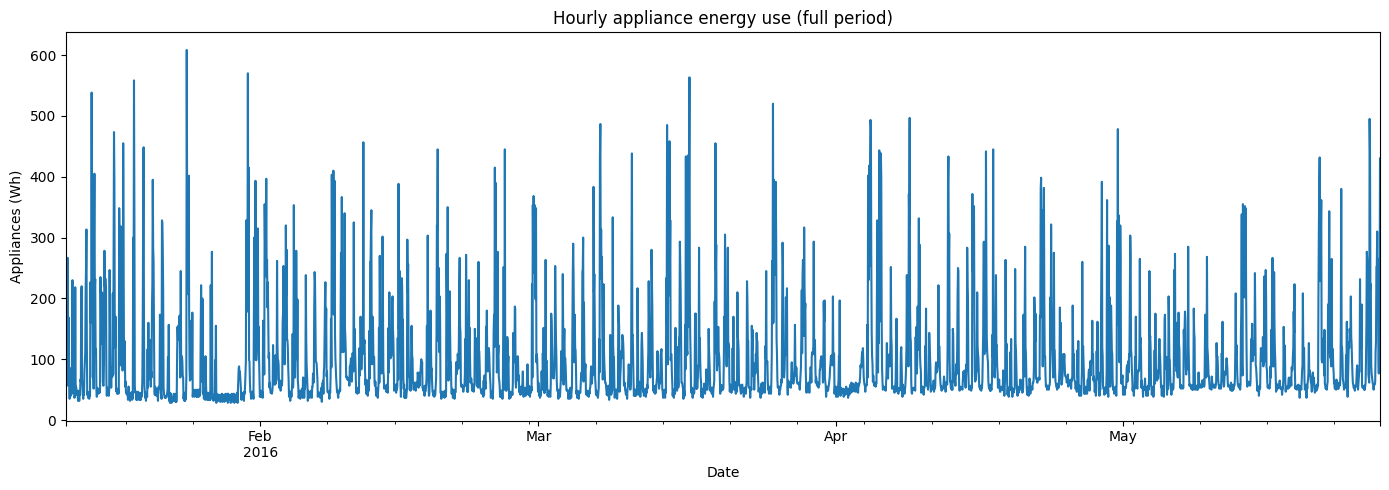

In [8]:
fig, ax = plotting.plot_time_series(
    hourly[config.TARGET],
    title="Hourly appliance energy use (full period)",
    ylabel="Appliances (Wh)",
)
plotting.save_fig(fig, config.FIGURE_DIR / "01_hourly_appliances_full_period.png")
plt.show()

In [9]:
hourly[config.TARGET].describe()

count    3290.000000
mean       97.779129
std        81.213695
min        28.333333
25%        50.000000
50%        63.333333
75%       110.000000
max       608.333333
Name: Appliances, dtype: float64